# Description

#

#

#

## Set Up

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))
project_root

PosixPath('/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine')

In [2]:
from src.job_intel.config import INTERIM_NORM_TITLE

## Libraries

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
from collections import Counter

## Data

In [4]:
df = pd.read_csv(INTERIM_NORM_TITLE)
df.head()

,Job Title,Job Description,Rating,Size,Founded,Industry,Sector,state,state_hq,sal_min,...,job_title_raw,clean_title_and_roman,job_title_base,seniority_roman,seniority,cluster,domain,job_title_norm,job_title_family,job_title_clean
0,Senior Data Scientist,"ABOUT HOPPER\n\nAt Hopper, we’re on a mission ...",3.5,501 to 1000 employees,2007.0,Travel Agencies,Travel & Tourism,NY,international,111000.0,...,Senior Data Scientist,"('data scientist', None)",data scientist,NaN,senior,14,general_data,data scientist,data_scientist,general_data data_scientist
1,"Data Scientist, Product Analytics","At Noom, we use scientifically proven methods ...",4.5,1001 to 5000 employees,2008.0,"Health, Beauty, & Fitness",Consumer Services,NY,NY,111000.0,...,"Data Scientist, Product Analytics","('data scientist product analytics', None)",data scientist product analytics,NaN,unknown,1,business,data scientist analyst,data_scientist,business data_scientist
2,Data Science Manager,Decode_M\n\nhttps://www.decode-m.com/\n\nData ...,NaN,1 to 50 employees,NaN,NaN,NaN,NY,NY,111000.0,...,Data Science Manager,"('data science', None)",data science,NaN,manager,14,general_data,data scientist,data_scientist,general_data data_scientist
3,Data Analyst,Sapphire Digital seeks a dynamic and driven mi...,3.4,201 to 500 employees,2019.0,Internet,Information Technology,NJ,NJ,111000.0,...,Data Analyst,"('data analyst', None)",data analyst,NaN,unknown,25,general_data,data analyst,data_analyst,general_data data_analyst
4,"Director, Data Science","Director, Data Science - (200537)\nDescription...",3.4,51 to 200 employees,2007.0,Advertising & Marketing,Business Services,NY,NY,111000.0,...,"Director, Data Science","('data science', None)",data science,NaN,manager,14,general_data,data scientist,data_scientist,general_data data_scientist


# Skill dictionary

## Initial job description clean

- Inheritance of the `noise_terms` list contructed for title normalisation to reduce some of the noise. We added additional generic job description words to complement the filtering.
- Remove generic stopwords
- Remove single digits
- Remove tokens with 3 or more digits
- Remove duplicate words within a job description.
- Remove words with an between-description-frequency of less than 10.


We aggressively clean the job descriptions to ensure that the token vocabulary fed into SBERT contains only meaningful, semantically useful words. Raw descriptions produce tens of thousands of noisy tokens—numbers, punctuation variants, locations, company names, typos, HR fluff, and one-off junk—that would overwhelm SBERT and cause clusters to mix real skills with irrelevant noise. By removing rare tokens, stopwords, numbers, noise words, and broken text, we create a stable, high-quality vocabulary that allows SBERT to form accurate semantic groups of genuine skills.

In [5]:
# Noise tokens

noise_terms = [

    # -------------------------------------------------
    # Contract / job-advert / recruiting meta
    # -------------------------------------------------
    "contract", "temporary", "temp",
    "full time", "part time", "fulltime", "full", "time", "part",
    "freelance", "seasonal",
    "hire", "hiring",
    "opportunity", "opportunities",
    "urgent", "immediate", "immediate start", "asap", "start",
    "apply now", "now hiring", "hiring", "now", "apply",
    "opening", "openings", "job opening",
    "position", "positions", "post", "posting",
    "reposted", "itjobs",
    "jobs", "job", "careers", "candidate",

    # -------------------------------------------------
    # Work mode / location-independent pattern
    # -------------------------------------------------
    "remote", "hybrid", "onsite", "on-site",
    "wfh", "work from home", "telecommute", "work", "home",
    "from",

    # -------------------------------------------------
    # Time / schedule / seniority-like ordinals
    # (we handle roman numerals separately)
    # -------------------------------------------------
    "month", "months", "year", "years",
    "day", "days", "week", "weeks", "hours",
    "shift", "roster", "tuesday", "saturday",
    "weekend", "weekends", "weekly",
    "evenings", "evening", "nights", "night",
    "2nd", "3rd", "1st",
    "pm", "am", "00pm", "30pm",
    "yr", "yrs", "late", "stage",

    # -------------------------------------------------
    # Eligibility / HR boilerplate / generic HR meta
    # -------------------------------------------------
    "relocation", "eligibility",
    "visa", "sponsorship",
    "anywhere", "compensation",
    "resident", "candidates",
    "required", "must",
    "incentives", "proficiency",
    "identity", "enrollment",
    "permanent",

    # -------------------------------------------------
    # Generic stopwords (safe to strip from titles)
    # -------------------------------------------------
    "and", "or", "with", "in", "of", "for",
    "to", "the", "at", "only", "on", "is",
    "up", "may", "as",
    "my", "re", "from",
    "into", "over", "all", "two",

    # -------------------------------------------------
    # Junk / corrupted tokens
    # -------------------------------------------------
    "s", "w", "t", "f", "bm", "ts", "â", "area4",
    "_", "_long", "d",
    "‰øùÂÆû‰π†‰øùÂ∞±‰∏ö",
    "x", "ch",
    "ihha", "ctj", "hsv",
    "mbse", "dw", "edw",
    "lrec", "idq",
    "c3", "e3", "1q",

    # -------------------------------------------------
    # Pure location tokens (we have a location column)
    # -------------------------------------------------
    # US states
    "ny", "nj", "ct", "fl", "oh", "pa", "tx", "mn", "wi",
    "nc", "sc", "al", "tn", "ky", "va", "wv", "md", "de",
    # Cities, regions, countries, generic geo
    "dallas", "chicago", "austin", "atlanta",
    "toronto", "washington", "antonio",
    "moines", "louis", "columbus", "nationwide",
    "ca", "san", "us", "la", "phoenix",
    "diego", "houston", "irving", "philadelphia",
    "francisco", "jolla", "south",
    "jacksonville", "atx", "local",
    "jersey", "jose", "ga", "california", "los",
    "angeles", "usa", "square", "sfo",
    "oklahoma", "bay", "nyc", "sf", "charlotte",
    "america", "york", "dc", "chandler",
    "canada", "tempe", "fargo", "wells",
    "east", "lake", "sinai", "harborside",
    "international", "mount", "missouri",
    "stafford", "sugar", "land", "arizona",
    "americas", "glendale", "scottsdale",
    "mesa", "gilbert", "burbank", "culver",
    "europe", "aurora", "arlington", "plano",
    "grand", "prairie", "wilmington", "lawson",
    "uk", "greenwood", "ohio",
    "india", "texas",
    # Extra locations / geo-ish
    "seattle", "denver", "norfolk", "whittier",
    "woodridge", "cerritos", "glenview",
    "bellaire", "hills", "hickory",
    "beach", "village", "acorn", "centennial",
    "midwest", "west", "ocean",

    # -------------------------------------------------
    # Languages / language requirements (not role type)
    # -------------------------------------------------
    "fluent", "speaking",
    "language",

    # -------------------------------------------------
    # Companies / organisations / brand names
    # (not role semantics)
    # -------------------------------------------------
    "disney", "hbo", "star", "max",
    "fleishmanhillard", "veritystream", "abbott", "dell",
    "gao", "cowen", "pfk", "usdc",
    "provost", "quantumblack", "fbi", "outsights", "lacera",
    "kaiser", "tyson", "bernard",
    "ais", "avmed", "hutchinson",
    "teleflora", "facilitysource",
    "publicis", "wirecutter",
    "peacock", "anderson", "kapil",
    "bhalla", "cedars", "svendsen",
    "novi", "gtech", "point72",
    "acurian", "ppd", "horsham",
    "schaeffer", "atlantic",
    "hctra", "gnhcc", "qsight", "sdsa", "sdma",
    "applecare", "upstart", "cognizant", "jll", "deloitte", "lilly",
    "cooper", "spotify",

    # -------------------------------------------------
    # Generic descriptors / fluff not needed in title
    # -------------------------------------------------
    "experienced", "online",
    "background", "future", "professional",
    "summer", "work", "fall", "main",
    "acceptance", "affordable", "ignite",
    "career", "early",  "assurance", "experience",
    "top", "new", "world", "multiple", "strong", "smart",
    "high", "fully", "first", "fast", "moving", "extensive",

    # -------------------------------------------------
    # ID codes / acronyms / job ids
    # -------------------------------------------------
    "w2", "c2c", "c4i",
    "70445br", "66201br",
    "jr1013810", "d3529", "ek020719a",
    "addm04", "s02268p", "7199u",
    "kp4457495", "84r", "daqa07",
    "jc2001", "jc2002",
    "bhjob11946_", "txho_", "opening_type",
    "null", "1yr", "150k", "1s",
    "pk", "ht", "mt", "sd", "mm", "pp",
    "qm", "rq", "dq", "mg",
    "cbch", "fhc", "cij",
    "x12", "euv", "ec",
    "usmtf", "niwc", "sisw",

    # -------------------------------------------------
    # Misc advert / presentation / filler words
    # -------------------------------------------------
    "now", "exciting", "needed", "please",
    "home",  "things", "cities", "begin",
    "also", "works", "bus", "ab", "go", "etc",
    "items", "item", "amazing", "superstar", "description",

    # -------------------------------------------------
    # Misc acronyms with no title meaning
    # -------------------------------------------------
    "eib", "rm", "pbm", "ams", "edss", "mpk", "lll",
    "ww", "em", "ipp", "ho", "dm", "ut",
    "sd", "mm", "pp", "rt", "jl", "ll",

    # -------------------------------------------------
    # Education / training fluff (not academic roles)
    # -------------------------------------------------
    "thesis", "educational",

    # -------------------------------------------------
    # Misc extremely generic / filler / junk
    # -------------------------------------------------
    "e", "adjustment", "across", "driven", "sm",
    "online", "site", "space",
    "stage", "point", "line", "place",
    "area", "inside", "next", "end",
    "back", "round", "side", "look",
    "get", "consider", "plenty", "eventually",
    "over", "specifically",

    # -------------------------------------------------
    # Extra generic job-board / advert noise
    # -------------------------------------------------
    "apply", "seller", "buyer", "store",

    # -------------------------------------------------
    # Generic business verbs (NOT skills)
    # -------------------------------------------------
    "manage", "managed", "managing",
    "support", "supported", "supporting",
    "develop", "developed", "developing",
    "deliver", "delivered", "delivering",
    "lead", "led", "leading",
    "assist", "assisted", "assisting",
    "provide", "provided", "providing",
    "maintain", "maintained", "maintaining",
    "perform", "performed", "performing",
    "ensure", "ensured", "ensuring",

    # -------------------------------------------------
    # Motivational fluff / emotional tone
    # -------------------------------------------------
    "great", "excellent", "amazing", "fantastic",
    "motivated", "dynamic", "passionate",
    "enthusiastic", "driven", "proactive",
    "self", "starter", "hardworking",
    "strong", "effective", "outstanding",

    # -------------------------------------------------
    # HR / compliance / policy language
    # -------------------------------------------------
    "compliance", "regulatory", "regulations",
    "eligible", "eligibility", "accommodation",
    "veteran", "disability", "inclusive",
    "diversity", "equity", "inclusion",

    # -------------------------------------------------
    # Reporting + documentation fluff
    # -------------------------------------------------
    "report", "reports", "reporting",
    "document", "documents", "documentation",
    "prepare", "prepared", "preparing",
    "analysis", "analyze", "analyzed", "analyzing",
    "insight", "insights", "summaries",

    # -------------------------------------------------
    # Generic nouns with no semantic value
    # -------------------------------------------------
    "project", "projects", "solutions",
    "functions", "functionality",
    "process", "processes",
    "organization", "team", "teams",
    "department", "departments",

    # -------------------------------------------------
    # Temporal/recurrence words (not skills)
    # -------------------------------------------------
    "daily", "weekly", "annually", "quarterly",
    "frequently", "occasionally", "sometimes",
    "schedule", "timelines", "milestones",

    # -------------------------------------------------
    # Soft-skill fluff (NOT real soft skills)
    # -------------------------------------------------
    "ability", "capable", "willing", "adaptable",
    "fast", "paced", "effectively",
]



In [6]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))
noise_token_set = set(noise_terms)

def surface_cleaning(text):
    if not isinstance(text, str):
        return ""

    # lowercase
    text = text.lower()

    # keep letters, digits, ".", and "+"
    text = re.sub(r"[^a-z0-9.+]+", " ", text)

    tokens = text.split()

    cleaned = []
    seen = set()

    for tok in tokens:
        # stopwords
        if tok in stop_words:
            continue

        # title-noise tokens
        if tok in noise_token_set:
            continue

        # pure numbers
        if tok.isdigit():
            continue

        # tokens with 3+ digits
        if len(re.findall(r"\d", tok)) >= 3:
            continue

        # dedupe while preserving order
        if tok not in seen:
            cleaned.append(tok)
            seen.add(tok)

    return " ".join(cleaned)


In [7]:

df['description_first_clean'] = df['Job Description'].apply(surface_cleaning)

In [9]:
df[['Job Description', 'description_first_clean']]

,Job Description,description_first_clean
0,"ABOUT HOPPER\n\nAt Hopper, we’re on a mission ...",hopper mission make booking travel faster easi...
1,"At Noom, we use scientifically proven methods ...",noom use scientifically proven methods help us...
2,Decode_M\n\nhttps://www.decode-m.com/\n\nData ...,decode https www.decode m.com data science man...
3,Sapphire Digital seeks a dynamic and driven mi...,sapphire digital seeks mid level data analyst ...
4,"Director, Data Science - (200537)\nDescription...",director data science edelman intelligence see...
...,...,...
6157,Maintains systems to protect data from unautho...,maintains systems protect data unauthorized us...
6158,Position:\nSenior Data Analyst (Corporate Audi...,senior data analyst corporate audit youll dete...
6159,"Title: Technical Business Analyst (SQL, Data a...",title technical business analyst sql data anal...
6160,Summary\n\nResponsible for working cross-funct...,summary responsible working cross functionally...


In [10]:
# create a word-count column
df["description_word_count"] = df["description_first_clean"].fillna("").apply(lambda x: len(x.split()))

# compute stats
max_wc = df["description_word_count"].max()
avg_wc = df["description_word_count"].mean()

max_wc, avg_wc


(np.int64(786), np.float64(196.7792924375203))

### Seniority within job description

In [11]:
principal = [r"\bprincipal\b"]

executive = [
    r"\bchief\b",
    r"\bchief [a-z]+ officer\b",
    r"\bvice president\b",
    r"\bsvp\b",
    r"\bvp\b",
    r"\bexecutive\b",
]

assistant = [
    r"\bassistant\b",
]

supervisor = [
    r"\bsupervisor\b",
    r"\bsupervisory\b",
]

lead = [
    r"\bteam lead\b",
    r"\btech lead\b",
]

senior = [
    r"\bsenior\b",
    r"\bsr\b",
    r"\bsr\.\b",
]

manager = [
    r"\bmanager\b",
    r"\bdirector\b",
    r"\bhead of\b",
    r"\bhead[- ]?[\w ]*department\b",
    r"\bofficer\b",
    r"\bavp\b",
]

mid = [
    r"\bmid[- ]?level\b",
    r"\bassociate\b",
    r"\bintermediate\b",
]

junior = [
    r"\bjunior\b",
    r"\bjr\b",
    r"\bjr\.\b",
    r"\bentry level\b",
    r"\binternship\b",
    r"\bintern\b",
    r"\btrainee\b",
    r"\bunpaid\b",
]

# priority order: higher first
seniority_patterns = [
    ("principal",  principal),
    ("executive",  executive),
    ("manager",    manager),
    ("lead",       lead),
    ("senior",     senior),
    ("mid",        mid),
    ("junior",     junior),
    ("assistant",  assistant),
    ("supervisor", supervisor),
]




In [12]:
def detect_seniority(text):
    if not isinstance(text, str):
        return "unknown"

    x = text.lower()
    # optional: restrict to first N chars to avoid noisy paragraphs
    snippet = x[:300]

    for label, patterns in seniority_patterns:
        for pat in patterns:
            if re.search(pat, snippet):
                return label

    return "unknown"

In [13]:
df["seniority_description"] = (
    df["description_first_clean"].fillna("").apply(detect_seniority)
)

In [14]:
def combine_seniority(desc_val, title_val):
    if desc_val and desc_val != "unknown":
        return desc_val
    return title_val if title_val else "unknown"

df["seniority_combined"] = df.apply(
    lambda row: combine_seniority(row["seniority_description"], row["seniority"]),
    axis=1
)

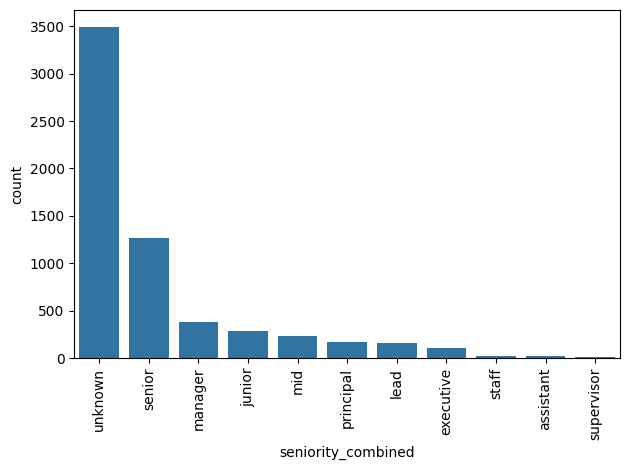

In [15]:
order = df['seniority_combined'].value_counts().index

sns.countplot(
    data = df,
    x = 'seniority_combined',
    order = order
)
plt.xticks(rotation = 90)
plt.tight_layout()

### Filter - Remove any word where the overall frequency is less than 10.

In [23]:
# Count tokens across ALL cleaned descriptions
freqs = Counter()
for t in df["description_first_clean"]:
    freqs.update(t.split())

# Make vocabulary of allowed tokens
allowed_tokens = {tok for tok, cnt in freqs.items() if cnt >= 15}


In [24]:
def final_clean_after_freq(text):
    if not isinstance(text, str):
        return ""
    tokens = text.split()
    tokens = [t for t in tokens if t in allowed_tokens]
    return " ".join(tokens)

df["description_first_clean_v2"] = df["description_first_clean"].apply(final_clean_after_freq)


In [25]:
# create a word-count column
df["description_word_count_v2"] = df["description_first_clean_v2"].fillna("").apply(lambda x: len(x.split()))

# compute stats
max_wc = df["description_word_count_v2"].max()
avg_wc = df["description_word_count_v2"].mean()

max_wc, avg_wc

(np.int64(664), np.float64(182.34534242129178))

In [26]:
df.head()

,Job Title,Job Description,Rating,Size,Founded,Industry,Sector,state,state_hq,sal_min,...,domain,job_title_norm,job_title_family,job_title_clean,description_first_clean,description_word_count,seniority_description,seniority_combined,description_first_clean_v2,description_word_count_v2
0,Senior Data Scientist,"ABOUT HOPPER\n\nAt Hopper, we’re on a mission ...",3.5,501 to 1000 employees,2007.0,Travel Agencies,Travel & Tourism,NY,international,111000.0,...,general_data,data scientist,data_scientist,general_data data_scientist,hopper mission make booking travel faster easi...,217,unknown,senior,mission make travel faster easier leveraging p...,202
1,"Data Scientist, Product Analytics","At Noom, we use scientifically proven methods ...",4.5,1001 to 5000 employees,2008.0,"Health, Beauty, & Fitness",Consumer Services,NY,NY,111000.0,...,business,data scientist analyst,data_scientist,business data_scientist,noom use scientifically proven methods help us...,155,unknown,unknown,use scientifically proven methods help users c...,142
2,Data Science Manager,Decode_M\n\nhttps://www.decode-m.com/\n\nData ...,NaN,1 to 50 employees,NaN,NaN,NaN,NY,NY,111000.0,...,general_data,data scientist,data_scientist,general_data data_scientist,decode https www.decode m.com data science man...,200,manager,manager,https data science manager office clients adva...,185
3,Data Analyst,Sapphire Digital seeks a dynamic and driven mi...,3.4,201 to 500 employees,2019.0,Internet,Information Technology,NJ,NJ,111000.0,...,general_data,data analyst,data_analyst,general_data data_analyst,sapphire digital seeks mid level data analyst ...,152,mid,mid,digital seeks mid level data analyst qa join g...,150
4,"Director, Data Science","Director, Data Science - (200537)\nDescription...",3.4,51 to 200 employees,2007.0,Advertising & Marketing,Business Services,NY,NY,111000.0,...,general_data,data scientist,data_scientist,general_data data_scientist,director data science edelman intelligence see...,171,manager,manager,director data science intelligence seeking lev...,158


## Embeddings

After cleaning, we extract the unique tokens that appear across job descriptions and embed each token using SBERT (MiniLM). We then run HDBSCAN or KMeans on the embeddings to group semantically similar words together—e.g., {"python", "r", "sql"} or {"aws", "azure", "gcp"}. We manually label these clusters, identifying which groups represent technical skills, soft skills, domain skills, or noise. All tokens from skill-related clusters become our skills dictionary, which we then use in a simple dictionary-based extractor to identify skills in each job posting.

In [27]:
# Compare RAW and CLEANED description word count
# ----------------------------
# 1. Tokenize RAW descriptions
# ----------------------------
def tokenize_raw(text):
    if not isinstance(text, str):
        return []
    # split on any sequence of letters/numbers/./+/- 
    return re.findall(r"[A-Za-z0-9\.\+\-]+", text.lower())

raw_tokens = []
for t in df["Job Description"]:
    raw_tokens.extend(tokenize_raw(t))

raw_unique = set(raw_tokens)


# -----------------------------------
# 2. Tokenize CLEANED descriptions
# -----------------------------------
clean_tokens = []
for t in df["description_first_clean"]:
    if isinstance(t, str):
        clean_tokens.extend(t.split())

clean_unique = set(clean_tokens)


# ----------------------------
# 3. Print comparison summary
# ----------------------------
print("RAW unique tokens:", len(raw_unique))
print("CLEAN unique tokens:", len(clean_unique))
print("Reduction:", len(raw_unique) - len(clean_unique))
print(
    "Percent reduction:",
    round(100 * (len(raw_unique) - len(clean_unique)) / len(raw_unique), 2),
    "%"
)

RAW unique tokens: 45600
CLEAN unique tokens: 37310
Reduction: 8290
Percent reduction: 18.18 %


In [28]:
unique_tokens = sorted(allowed_tokens)
len(unique_tokens)

6996

In [ ]:
skill_dict = [   # Cloud / data platforms
                "azure", "sap", "teradata", "workday", "salesforce",
                "splunk", "hana", "collibra", "mongodb", "oracle",
                "hive", "snowflake", "databricks", "powerbi",
                "kafka", "kubernetes", "docker", "talend",
                "geospatial", "arcgis", "erp", "lims", "cloudera",
                "greenplum", "memsql", "celonis", "websphere",
                "sharepoint", "infosphere", "hpc",

                # Programming languages / frameworks
                "python", "java", "r", "sas", "nlp",
                "plsql", "sql", "xml", "csv", "js",

                # Data / ML / devops
                "etl", "cloud", "hadoop", "spark",
                "crm", "mdm", "aws", "devops", "cloudops",
                "pyspark", "datamodeling",

                # Misc tools / tech-y but not core role type
                "guidewire", "hub", "ecommerce", "datastage", "stack",
                "informatica", "pcr", "hplc",
                "gpu", "polygraph",
                "nifi", "elasticsearch", "logstash",
                "portal", "sdk", "cli", "scala",
                "ecomm", "systemc", "oci", "ci", "cd",
                "datalakes", "kibana", "tableau", "toad",
                "qliksense", "spotfire", "jupyter", "notebook",
                "server", "app", "apps", "node", "cpu", "graphics",
                "communication", "reporting", "bachelor", "bachelors",
                'collaborate'
                ]